In [ ]:
$env:Path += ";C:\Users\mxlab\anaconda3\Scripts;C:\Users\mxlab\anaconda3\Library\bin"   

In [ ]:
conda create -y -p C:/Users/mxlab/Documents/SCENIC_R/pyscenic python=3.10   

In [2]:
pip install -r requirements.txt

  Using cached ctxcore-0.2.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached cytoolz-1.0.1-cp310-cp310-win_amd64.whl.metadata (4.7 kB)
  Using cached multiprocessing_on_dill-3.5.0a4-py3-none-any.whl
  Using cached llvmlite-0.44.0-cp310-cp310-win_amd64.whl.metadata (5.0 kB)
  Using cached numba-0.61.0-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached attrs-25.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached frozendict-2.4.6-cp310-cp310-win_amd64.whl.metadata (23 kB)
  Using cached pandas-2.2.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numexpr-2.10.2-cp310-cp310-win_amd64.whl.metadata (8.3 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached dask-2025.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached distributed-2025.2.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached arboreto-0.1.6-py2.py3-none-any.whl.metadata (5.4 kB)
  Using cached boltons-25.0.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached PyYAML-6.0.2-cp310

In [3]:
pip install pyscenic

  Using cached pyscenic-0.12.1-py3-none-any.whl.metadata (9.8 kB)
Using cached pyscenic-0.12.1-py3-none-any.whl (7.1 MB)
Note: you may need to restart the kernel to use updated packages.


Has to change in pyscenic/transform.py :
("Enrichment", COLUMN_NAME_ANNOTATION): np.object,
("Enrichment", COLUMN_NAME_CONTEXT): np.object,
("Enrichment", COLUMN_NAME_TARGET_GENES): np.object,
to
("Enrichment", COLUMN_NAME_ANNOTATION): object,
("Enrichment", COLUMN_NAME_CONTEXT): object,
("Enrichment", COLUMN_NAME_TARGET_GENES): object

In [7]:
pip install scanpy

  Using cached scanpy-1.11.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached anndata-0.11.3-py3-none-any.whl.metadata (8.2 kB)
  Using cached legacy_api_wrap-1.4.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached scikit_learn-1.5.2-cp310-cp310-win_amd64.whl.metadata (13 kB)
  Using cached session_info2-0.1.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached statsmodels-0.14.4-cp310-cp310-win_amd64.whl.metadata (9.5 kB)
  Using cached array_api_compat-1.10.0-py3-none-any.whl.metadata (1.6 kB)
Using cached scanpy-1.11.0-py3-none-any.whl (2.1 MB)
Using cached anndata-0.11.3-py3-none-any.whl (142 kB)
Using cached legacy_api_wrap-1.4.1-py3-none-any.whl (10.0 kB)
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
Using cached scikit_learn-1.5.2-cp310-cp310-win_amd64.whl (11.0 MB)
Using cached statsmodels-0.14.4-cp310-cp310-win_amd64.whl (9.8 MB)
Using cached

  You can safely remove it manually.


In [11]:
pip install openTSNE


Note: you may need to restart the kernel to use updated packages.


In [44]:
import pandas as pd
import numpy as np
import os, glob
import pickle

from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2

from ctxcore.rnkdb import FeatherRankingDatabase as RankingDatabase
from pyscenic.utils import modules_from_adjacencies
from pyscenic.prune import prune2df, df2regulons
from pyscenic.aucell import aucell

import seaborn as sns
import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
from openTSNE import TSNE


## Set variable

In [2]:
# set variables for file paths to read from and write to:

# set a working directory
wdir = "C:/Users/mxlab/Documents/SCENIC_R"
os.chdir( wdir )

# path to count loom file
f_loom_path_unfilt = "ASC_counts.loom" # test dataset, n=500 cells

# # path to loom file with basic filtering applied (this will be created in the "initial filtering" step below). Optional.
f_loom_path_scenic = "ASC_scenic_count.loom"

# path to anndata object, which will be updated to store Scanpy results as they are generated below
f_anndata_path = "ASC.h5ad"

# path to pyscenic output
f_pyscenic_output = "pyscenic_output.loom"

# loom output, generated from a combination of Scanpy and pySCENIC results:
f_final_loom = 'ASC_scenic_integrated-output.loom'

In [3]:
adata = sc.read_h5ad( f_anndata_path )

not normalized

In [ ]:
#adata.write_loom(f_loom_path_scenic, write_obsm_varm=True)

In [ ]:
row_attrs = {
    "Gene": np.array(adata.var_names) ,
}
col_attrs = {
    "CellID": np.array(adata.obs_names) ,
    "nGene": np.array( np.sum(adata.X.transpose()>0 , axis=0)).flatten() ,
    "nUMI": np.array( np.sum(adata.X.transpose() , axis=0)).flatten() ,
}
lp.create( f_loom_path_scenic, adata.X.transpose(), row_attrs, col_attrs)

In [56]:
ds = loompy.connect(f_loom_path_scenic, mode="r")

In [57]:
print("Layers:", ds.layers.keys())
print("Row attributes (genes):", ds.ra.keys())  # Gene metadata
print("Column attributes (cells):", ds.ca.keys())  # Cell metadata
ds.close()

Layers: ['']
Row attributes (genes): ['Gene']
Column attributes (cells): ['CellID', 'nGene', 'nUMI']


In [4]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,tissue,condition,mitoRatio,log10GenesPerUMI,multiplet_class,nCount_SCT,nFeature_SCT,...,SCT_snn_res.0.12,SCT_snn_res.0.13,celltype_TM,celltype_pred,quality,SCT_snn_res.0.18,clusters_name,barcode,UMAP_1,UMAP_2
barcode,,,,,,,,,,,,,,,,,,,,,
scAT_CTL_AAACCCACAGCGGATA-1,scAT_CTL,6162,2150,scAT,NI,0.034567,0.879336,singlet,10723,2198,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCACAGCGGATA-1,-7.109205,3.641288
scAT_CTL_AAACCCACATTCACCC-1,scAT_CTL,7371,2443,scAT,NI,0.023470,0.875992,singlet,10630,2446,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCACATTCACCC-1,6.057202,2.563345
scAT_CTL_AAACCCAGTAGCGTAG-1,scAT_CTL,17854,3850,scAT,NI,0.005377,0.843293,singlet,12115,3765,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCAGTAGCGTAG-1,-7.382786,-1.840516
scAT_CTL_AAACCCATCGACCTAA-1,scAT_CTL,9697,2636,scAT,NI,0.015262,0.858103,singlet,10890,2628,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCATCGACCTAA-1,-6.301454,0.901802
scAT_CTL_AAACGAAAGATTTGCC-1,scAT_CTL,10026,2475,scAT,NI,0.017554,0.848155,singlet,10971,2464,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACGAAAGATTTGCC-1,-6.765811,0.774978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,scAT_24h,6169,2098,scAT,Inj_24h,0.056573,0.876416,singlet,10685,2129,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_24h_TTTGGTTTCATTACCT-1,-2.861776,4.463135
scAT_24h_TTTGGTTTCCGCTTAC-1,scAT_24h,11687,3205,scAT,Inj_24h,0.028750,0.861869,singlet,11565,3191,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGGTTTCCGCTTAC-1,2.881420,-0.045198
scAT_24h_TTTGTTGAGCCTGACC-1,scAT_24h,6594,2277,scAT,Inj_24h,0.019108,0.879087,singlet,10654,2287,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGTTGAGCCTGACC-1,4.395781,-1.872556


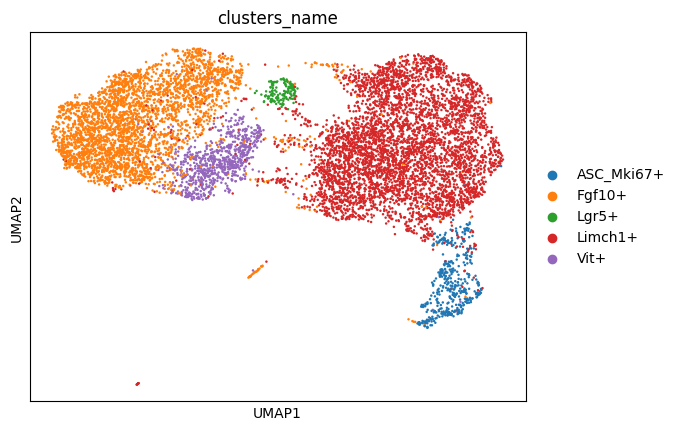

In [5]:
sc.pl.umap(adata, color=['clusters_name'])

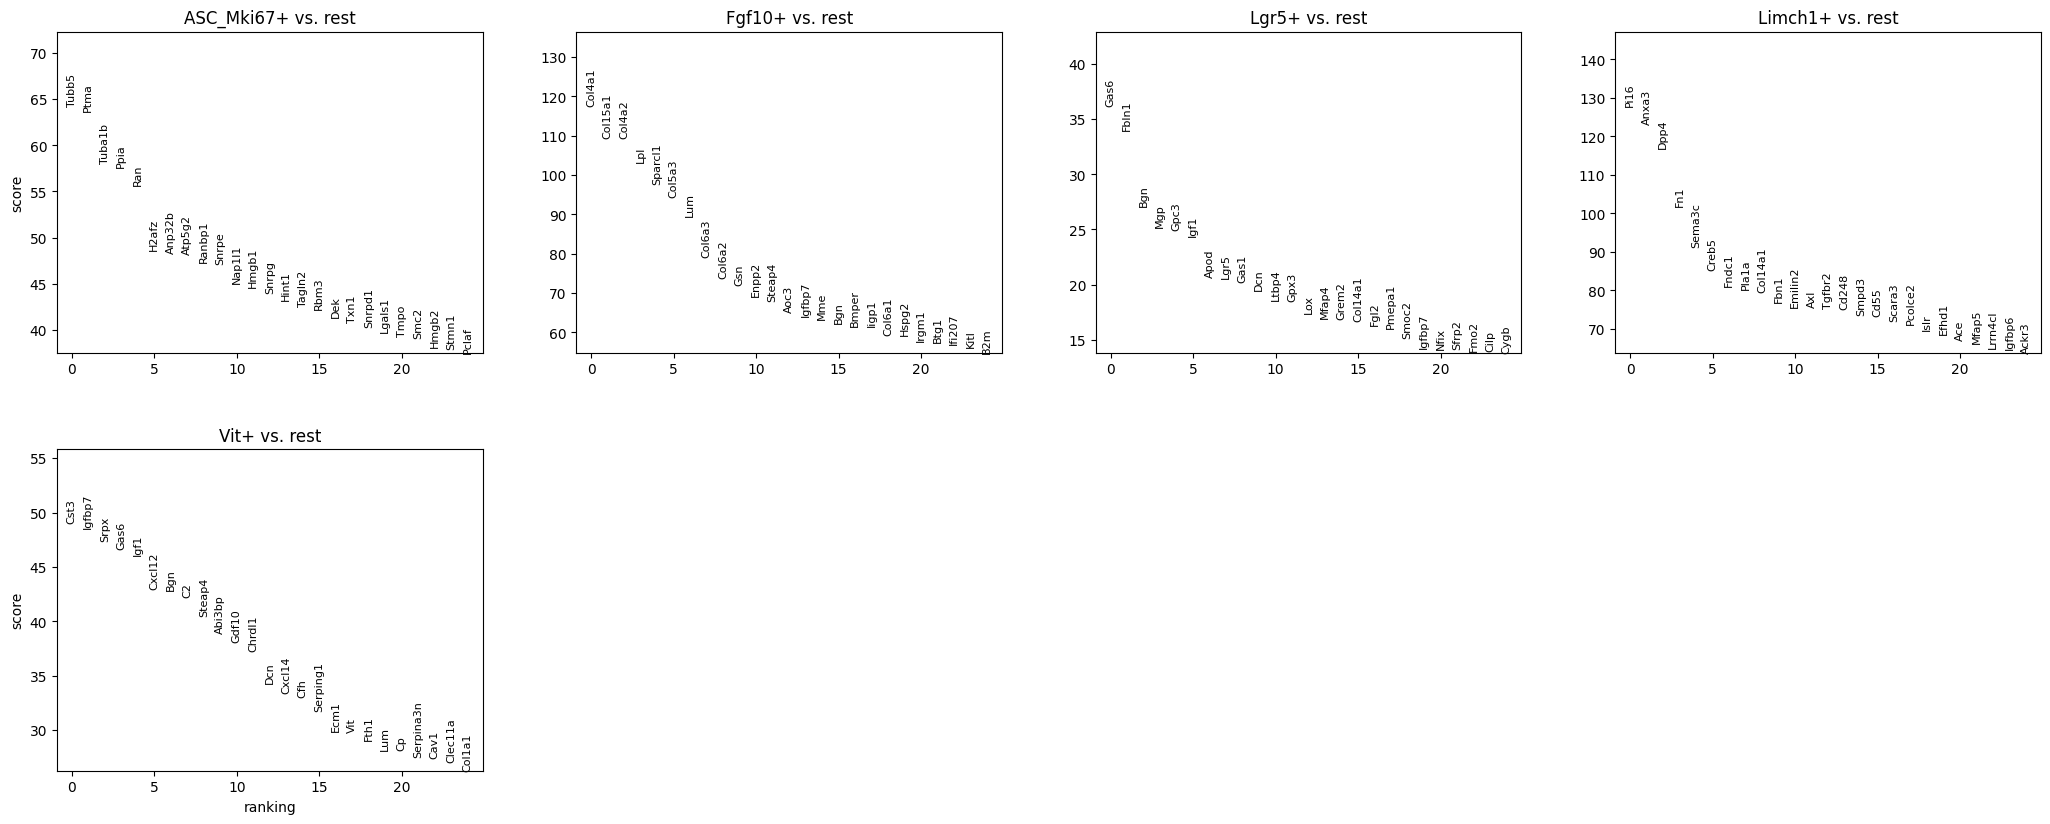

In [10]:
# find marker genes
sc.tl.rank_genes_groups(adata, 'clusters_name', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [6]:
# Set maximum number of jobs for Scanpy.
sc.settings.njobs = 20

# SCENIC steps


In [7]:
import loompy


In [8]:
ds = loompy.connect(f_loom_path_scenic, mode="r")


In [9]:
print(ds.ca.keys())  # Check cell attributes
print(ds.ra.keys())  # Check gene attributes
ds.close()

['CellID', 'nGene', 'nUMI']
['Gene']


## STEP 1: Gene regulatory network inference, and generation of co-expression modules


In [10]:
loom_path = f_loom_path_scenic  # Replace with your actual file path

try:
    ds = loompy.connect(loom_path, mode="r")
    print(f"Shape: {ds.shape}")  # Should be (genes, cells)
    print(f"Row attributes: {ds.ra.keys()}")  # Check gene names
    print(f"Column attributes: {ds.ca.keys()}")  # Check cell metadata
    ds.close()
except Exception as e:
    print("Error loading loom file:", e)

Shape: (21695, 9517)
Row attributes: ['Gene']
Column attributes: ['CellID', 'nGene', 'nUMI']


### Phase Ia: GRN inference using the GRNBoost2 algorithm


In [34]:
pip install dask-expr==0.5.3 distributed==2024.2.1 

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 6.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 8.9 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2025.2.0
    Uninstalling dask-2025.2.0:
      Successfully uninstalled dask-2025.2.0
  Attempting uninstall: distributed
    Found existing installation: distributed 2025.2.0
    Uninstalling distributed-2025.2.0:
      Successfully uninstalled distributed-2025.2.0
Note: you may need to restart the kernel to use updated packages.


In [11]:
import multiprocessing

print("Available CPU cores:", multiprocessing.cpu_count())


Available CPU cores: 16


In [12]:
import psutil

available_memory = psutil.virtual_memory().available / 1e9  # Convert bytes to GB
print(f"Available RAM: {available_memory:.2f} GB")

Available RAM: 5.90 GB


In [13]:
f_tfs = "allTFs_mm.txt"

21700 cell x 9500 genes, 2 CPU cores : 361 min = 6h 

In [39]:
!pyscenic grn {f_loom_path_scenic} {f_tfs} -o adj.csv --num_workers 2

preparing dask client
parsing input
creating dask graph
2 partitions
computing dask graph
not shutting down client, client was created externally
finished



2025-02-25 09:36:08,809 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-02-25 09:36:13,967 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.
c:\Users\mxlab\Documents\SCENIC_R\pyscenic\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60772 instead
  warnings.warn(
c:\Users\mxlab\Documents\SCENIC_R\pyscenic\lib\site-packages\distributed\client.py:3169: UserWarning: Sending large graph of size 1.45 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(

2025-02-25 15:36:42,738 - pyscenic.cli.pyscenic - INFO - Writing results to file.


read in the adjacencies matrix:



In [14]:
adjacencies = pd.read_csv("adj.csv", index_col=False, sep=',')

In [15]:
adjacencies.head()

,TF,target,importance
0,Plagl2,Wfdc12,17.788705
1,Rps10,Rps24,17.244283
2,Rps4x,Rps24,15.312359
3,Hspa5,Calr,14.486750
4,Rpl35,Rps28,14.173393


## STEP 2-3: Regulon prediction aka cisTarget from CLI


#### CAUTION : not enough RAM on computer has to run it on HPC

For this step the CLI version of SCENIC is used. This step can be deployed on an High Performance Computing system.



Output: List of adjacencies between a TF and its targets stored in MOTIFS_FNAME.



locations for ranking databases, and motif annotations:



In [16]:
import glob

In [17]:
# ranking databases
f_db_glob = "*feather"
f_db_names = ' '.join( glob.glob(f_db_glob) )

In [22]:
f_db_names

'mm9-500bp-upstream-7species.mc9nr.genes_vs_motifs.rankings.feather mm9-tss-centered-10kb-7species.mc9nr.genes_vs_motifs.rankings.feather'

In [19]:
# motif databases
f_motif_path = "motifs-v9-nr.mgi-m0.001-o0.0.tbl"

21700 cell x 9500 genes, 3 CPU cores : 1402 min pour l'instant -> 23h (estimation à 10-11h)

In [20]:
!pyscenic ctx adj.csv \
    {f_db_names} \
    --annotations_fname {f_motif_path} \
    --expression_mtx_fname {f_loom_path_scenic} \
    --output reg.csv \
    --mask_dropouts \
    --num_workers 2

^C


In [55]:
adata.var

""
Xkr4
Gm1992
Gm19938
Sox17
Gm37587
...
Gm15169
Gm15201
Frmpd4
Amelx


dans powershell : Get-Process pyscenic | Select-Object Name,Id,Threads,CPU 
Pour voir le nombre de threads et CPU utilisés

In [53]:
# Load regulons file
regulons = pd.read_csv("reg.csv")

# Extract unique TFs
unique_tfs = regulons["TF"].str.split("(").str[0].unique()

# Count the number of TFs
print(f"Number of unique TFs: {len(unique_tfs)}")

KeyError: 'TF'

## STEP 4: Cellular enrichment (aka AUCell) from CLI

It is important to check that most cells have a substantial fraction of expressed/detected genes in the calculation of the AUC. The following histogram gives an idea of the distribution and allows selection of an appropriate threshold. In this plot, a few thresholds are highlighted, with the number of genes selected shown in red text and the corresponding percentile in parentheses)

In [ ]:
nGenesDetectedPerCell = np.sum(adata.X > 0, axis=1)  # Sum across genes per cell
nGenesDetectedPerCell = pd.Series(np.array(nGenesDetectedPerCell).flatten())  # Convert to Pandas Series to have quantile

In [26]:
percentiles = nGenesDetectedPerCell.quantile([.01, .05, .10, .50, 1])
print(percentiles)

0.01    1112.16
0.05    1603.60
0.10    2023.00
0.50    3126.00
1.00    8330.00
dtype: float64


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\mxlab\AppData\Local\Temp\ipykernel_7748\897791332.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(nGenesDetectedPerCell, norm_hist=False, kde=False, bins='fd')


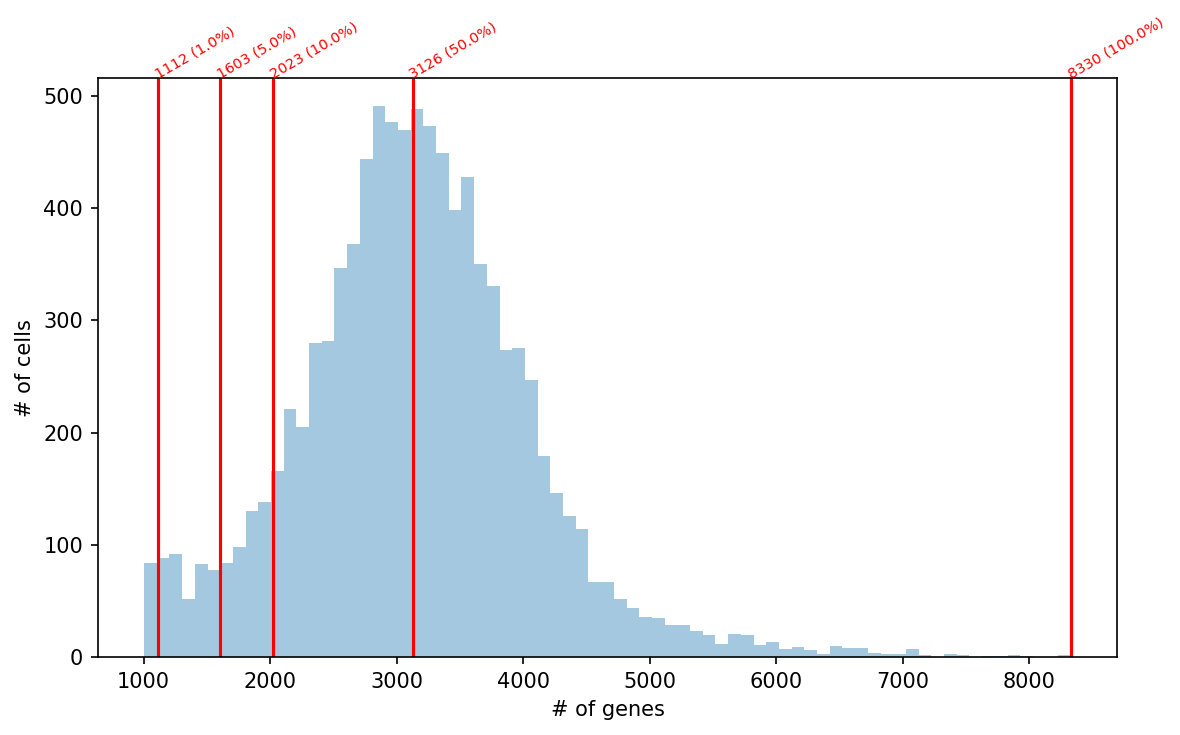

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=150)
sns.distplot(nGenesDetectedPerCell, norm_hist=False, kde=False, bins='fd')
for i,x in enumerate(percentiles):
    fig.gca().axvline(x=x, ymin=0,ymax=1, color='red')
    ax.text(x=x, y=ax.get_ylim()[1], s=f'{int(x)} ({percentiles.index.values[i]*100}%)', color='red', rotation=30, size='x-small',rotation_mode='anchor' )
ax.set_xlabel('# of genes')
ax.set_ylabel('# of cells')
fig.tight_layout()

## Visualization of SCENIC's AUC matrix

First, load the relevant data from the loom we just created



In [30]:
import json
import zlib
import base64

In [ ]:
# collect SCENIC AUCell output
lf = lp.connect( f_pyscenic_output, mode='r+', validate=False )
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)

In [ ]:
print("Layers:", lf.layers.keys())
print("Row attributes (genes):", lf.ra.keys())  # Gene metadata
print("Column attributes (cells):", lf.ca.keys())  # Cell metadata
lf.close()

Layers: ['']
Row attributes (genes): ['Gene', 'Regulons']
Column attributes (cells): ['CellID', 'RegulonsAUC', 'nGene', 'nUMI']


In [70]:
auc_mtx

,AU041133(+),Alx3(+),Ar(+),Arid3a(+),Arid5a(+),Arid5b(+),Atf2(+),Atf3(+),Atf4(+),Atf6(+),...,Zfp629(+),Zfp667(+),Zfp691(+),Zfp729a(+),Zfp787(+),Zfp821(+),Zfp846(+),Zfp932(+),Zkscan17(+),Zmiz1(+)
scAT_CTL_AAACCCACAGCGGATA-1,0.000000,0.000000,0.074010,0.000000,0.112961,0.091875,0.000000,0.087428,0.095418,0.141219,...,0.081659,0.0,0.0,0.000000,0.000000,0.021198,0.035023,0.0,0.084608,0.034123
scAT_CTL_AAACCCACATTCACCC-1,0.000000,0.000000,0.132401,0.000000,0.023675,0.059929,0.000000,0.079530,0.070507,0.065233,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.027083,0.0,0.028203,0.050149
scAT_CTL_AAACCCAGTAGCGTAG-1,0.000000,0.000000,0.124388,0.017563,0.086636,0.083431,0.000000,0.060142,0.101564,0.087097,...,0.000000,0.0,0.0,0.000000,0.013057,0.019355,0.000000,0.0,0.000000,0.041758
scAT_CTL_AAACCCATCGACCTAA-1,0.000000,0.000000,0.128569,0.015617,0.081970,0.100723,0.000000,0.067785,0.111161,0.058321,...,0.000000,0.0,0.0,0.018331,0.000000,0.000000,0.000000,0.0,0.000000,0.040047
scAT_CTL_AAACGAAAGATTTGCC-1,0.000000,0.001278,0.073115,0.000000,0.053111,0.151273,0.000000,0.069733,0.106959,0.092678,...,0.000000,0.0,0.0,0.000000,0.000000,0.082604,0.000000,0.0,0.000000,0.033079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,0.058618,0.000000,0.092407,0.041526,0.080588,0.086168,0.014483,0.109711,0.081887,0.088479,...,0.000000,0.0,0.0,0.017853,0.000000,0.000000,0.000000,0.0,0.000000,0.035327
scAT_24h_TTTGGTTTCCGCTTAC-1,0.000000,0.022685,0.147534,0.003123,0.010311,0.104360,0.000000,0.072264,0.101245,0.104455,...,0.000000,0.0,0.0,0.015498,0.000000,0.000000,0.000000,0.0,0.000000,0.050139
scAT_24h_TTTGTTGAGCCTGACC-1,0.000000,0.000000,0.092298,0.000000,0.044297,0.072024,0.000000,0.068674,0.093143,0.086738,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.044155
scAT_24h_TTTGTTGCATGACTCA-1,0.000000,0.015698,0.087871,0.000000,0.092224,0.075115,0.000000,0.062436,0.088728,0.082488,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.027142


In [76]:
num_tfs = auc_mtx.shape[1]
print(f"Number of Transcription Factors: {num_tfs}")

Number of Transcription Factors: 323


In [75]:
auc_mtx.shape

(9517, 323)

In [80]:
print(auc_mtx.columns) 

Index(['AU041133(+)', 'Alx3(+)', 'Ar(+)', 'Arid3a(+)', 'Arid5a(+)',
       'Arid5b(+)', 'Atf2(+)', 'Atf3(+)', 'Atf4(+)', 'Atf6(+)',
       ...
       'Zfp629(+)', 'Zfp667(+)', 'Zfp691(+)', 'Zfp729a(+)', 'Zfp787(+)',
       'Zfp821(+)', 'Zfp846(+)', 'Zfp932(+)', 'Zkscan17(+)', 'Zmiz1(+)'],
      dtype='object', length=323)


examine TF activity in the AUC matrix :

In [81]:
print(auc_mtx.head())

                             AU041133(+)   Alx3(+)     Ar(+)  Arid3a(+)  \
scAT_CTL_AAACCCACAGCGGATA-1          0.0  0.000000  0.074010   0.000000   
scAT_CTL_AAACCCACATTCACCC-1          0.0  0.000000  0.132401   0.000000   
scAT_CTL_AAACCCAGTAGCGTAG-1          0.0  0.000000  0.124388   0.017563   
scAT_CTL_AAACCCATCGACCTAA-1          0.0  0.000000  0.128569   0.015617   
scAT_CTL_AAACGAAAGATTTGCC-1          0.0  0.001278  0.073115   0.000000   

                             Arid5a(+)  Arid5b(+)  Atf2(+)   Atf3(+)  \
scAT_CTL_AAACCCACAGCGGATA-1   0.112961   0.091875      0.0  0.087428   
scAT_CTL_AAACCCACATTCACCC-1   0.023675   0.059929      0.0  0.079530   
scAT_CTL_AAACCCAGTAGCGTAG-1   0.086636   0.083431      0.0  0.060142   
scAT_CTL_AAACCCATCGACCTAA-1   0.081970   0.100723      0.0  0.067785   
scAT_CTL_AAACGAAAGATTTGCC-1   0.053111   0.151273      0.0  0.069733   

                              Atf4(+)   Atf6(+)  ...  Zfp629(+)  Zfp667(+)  \
scAT_CTL_AAACCCACAGCGGATA-1  0.095418 

In [ ]:
# Load the regulons file
regulons = pd.read_csv("reg.csv")

# List the unique TFs
unique_tfs = regulons["Regulon"].str.split("(").str[0].unique()
print(f"Number of unique TFs: {len(unique_tfs)}")
print("First few TFs:", unique_tfs[:5])

In [32]:
import umap

c:\Users\mxlab\Documents\SCENIC_R\pyscenic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
# UMAP
runUmap = umap.UMAP(n_neighbors=10, min_dist=0.4, metric='correlation').fit_transform
dr_umap = runUmap( auc_mtx )
pd.DataFrame(dr_umap, columns=['X', 'Y'], index=auc_mtx.index).to_csv( "scenic_umap.txt", sep='\t')
# tSNE
tsne = TSNE( n_jobs=20 )
dr_tsne = tsne.fit_transform( auc_mtx )
pd.DataFrame(dr_tsne, columns=['X', 'Y'], index=auc_mtx.index).to_csv( "scenic_tsne.txt", sep='\t')

AttributeError: 'TSNE' object has no attribute 'fit_transform'

## Integrate the output

Here, we combine the results from SCENIC and the Scanpy analysis into a SCope-compatible loom file



In [90]:
# scenic output
lf = lp.connect( f_pyscenic_output, mode='r+', validate=False )
meta = json.loads(zlib.decompress(base64.b64decode( lf.attrs.MetaData )))
#exprMat = pd.DataFrame( lf[:,:], index=lf.ra.Gene, columns=lf.ca.CellID)
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)
regulons = lf.ra.Regulons
dr_umap = pd.read_csv( 'scenic_umap.txt', sep='\t', header=0, index_col=0 )

In [91]:
regulons

array([(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
       (0, 0, 0, 0, 0,

In [92]:
auc_mtx

,AU041133(+),Alx3(+),Ar(+),Arid3a(+),Arid5a(+),Arid5b(+),Atf2(+),Atf3(+),Atf4(+),Atf6(+),...,Zfp629(+),Zfp667(+),Zfp691(+),Zfp729a(+),Zfp787(+),Zfp821(+),Zfp846(+),Zfp932(+),Zkscan17(+),Zmiz1(+)
scAT_CTL_AAACCCACAGCGGATA-1,0.000000,0.000000,0.074010,0.000000,0.112961,0.091875,0.000000,0.087428,0.095418,0.141219,...,0.081659,0.0,0.0,0.000000,0.000000,0.021198,0.035023,0.0,0.084608,0.034123
scAT_CTL_AAACCCACATTCACCC-1,0.000000,0.000000,0.132401,0.000000,0.023675,0.059929,0.000000,0.079530,0.070507,0.065233,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.027083,0.0,0.028203,0.050149
scAT_CTL_AAACCCAGTAGCGTAG-1,0.000000,0.000000,0.124388,0.017563,0.086636,0.083431,0.000000,0.060142,0.101564,0.087097,...,0.000000,0.0,0.0,0.000000,0.013057,0.019355,0.000000,0.0,0.000000,0.041758
scAT_CTL_AAACCCATCGACCTAA-1,0.000000,0.000000,0.128569,0.015617,0.081970,0.100723,0.000000,0.067785,0.111161,0.058321,...,0.000000,0.0,0.0,0.018331,0.000000,0.000000,0.000000,0.0,0.000000,0.040047
scAT_CTL_AAACGAAAGATTTGCC-1,0.000000,0.001278,0.073115,0.000000,0.053111,0.151273,0.000000,0.069733,0.106959,0.092678,...,0.000000,0.0,0.0,0.000000,0.000000,0.082604,0.000000,0.0,0.000000,0.033079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,0.058618,0.000000,0.092407,0.041526,0.080588,0.086168,0.014483,0.109711,0.081887,0.088479,...,0.000000,0.0,0.0,0.017853,0.000000,0.000000,0.000000,0.0,0.000000,0.035327
scAT_24h_TTTGGTTTCCGCTTAC-1,0.000000,0.022685,0.147534,0.003123,0.010311,0.104360,0.000000,0.072264,0.101245,0.104455,...,0.000000,0.0,0.0,0.015498,0.000000,0.000000,0.000000,0.0,0.000000,0.050139
scAT_24h_TTTGTTGAGCCTGACC-1,0.000000,0.000000,0.092298,0.000000,0.044297,0.072024,0.000000,0.068674,0.093143,0.086738,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.044155
scAT_24h_TTTGTTGCATGACTCA-1,0.000000,0.015698,0.087871,0.000000,0.092224,0.075115,0.000000,0.062436,0.088728,0.082488,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.027142


Fix regulon objects to display properly in SCope:



In [93]:
auc_mtx.columns = auc_mtx.columns.str.replace('\(','_(')
regulons.dtype.names = tuple( [ x.replace("(","_(") for x in regulons.dtype.names ] )
# regulon thresholds
rt = meta['regulonThresholds']
for i,x in enumerate(rt):
    tmp = x.get('regulon').replace("(","_(")
    x.update( {'regulon': tmp} )

Concatenate embeddings (tSNE, UMAP, etc.)



In [94]:
adata.obsm

AxisArrays with keys: X_pca, X_umap

In [95]:
umapDF = pd.DataFrame(adata.obsm['X_umap'], columns=['_X', '_Y'])


mbeddings_X = pd.DataFrame( index=lf.ca.CellID )
Embeddings_X = pd.concat( [
        pd.DataFrame(adata.obsm['X_umap'],index=adata.obs.index)[0] ,
        pd.DataFrame(adata.obsm['X_pca'],index=adata.obs.index)[0] ,
        dr_umap['X']
    ], sort=False, axis=1, join='outer' )
Embeddings_X.columns = ['1','2','3']

Embeddings_Y = pd.DataFrame( index=lf.ca.CellID )
Embeddings_Y = pd.concat( [
        pd.DataFrame(adata.obsm['X_umap'],index=adata.obs.index)[1] ,
        pd.DataFrame(adata.obsm['X_pca'],index=adata.obs.index)[1] ,
        dr_umap['Y']
    ], sort=False, axis=1, join='outer' )
Embeddings_Y.columns = ['1','2','3']

Metadata:



In [96]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,tissue,condition,mitoRatio,log10GenesPerUMI,multiplet_class,nCount_SCT,nFeature_SCT,...,SCT_snn_res.0.12,SCT_snn_res.0.13,celltype_TM,celltype_pred,quality,SCT_snn_res.0.18,clusters_name,barcode,UMAP_1,UMAP_2
barcode,,,,,,,,,,,,,,,,,,,,,
scAT_CTL_AAACCCACAGCGGATA-1,scAT_CTL,6162,2150,scAT,NI,0.034567,0.879336,singlet,10723,2198,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCACAGCGGATA-1,-7.109205,3.641288
scAT_CTL_AAACCCACATTCACCC-1,scAT_CTL,7371,2443,scAT,NI,0.023470,0.875992,singlet,10630,2446,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCACATTCACCC-1,6.057202,2.563345
scAT_CTL_AAACCCAGTAGCGTAG-1,scAT_CTL,17854,3850,scAT,NI,0.005377,0.843293,singlet,12115,3765,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCAGTAGCGTAG-1,-7.382786,-1.840516
scAT_CTL_AAACCCATCGACCTAA-1,scAT_CTL,9697,2636,scAT,NI,0.015262,0.858103,singlet,10890,2628,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCATCGACCTAA-1,-6.301454,0.901802
scAT_CTL_AAACGAAAGATTTGCC-1,scAT_CTL,10026,2475,scAT,NI,0.017554,0.848155,singlet,10971,2464,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACGAAAGATTTGCC-1,-6.765811,0.774978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,scAT_24h,6169,2098,scAT,Inj_24h,0.056573,0.876416,singlet,10685,2129,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_24h_TTTGGTTTCATTACCT-1,-2.861776,4.463135
scAT_24h_TTTGGTTTCCGCTTAC-1,scAT_24h,11687,3205,scAT,Inj_24h,0.028750,0.861869,singlet,11565,3191,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGGTTTCCGCTTAC-1,2.881420,-0.045198
scAT_24h_TTTGTTGAGCCTGACC-1,scAT_24h,6594,2277,scAT,Inj_24h,0.019108,0.879087,singlet,10654,2287,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGTTGAGCCTGACC-1,4.395781,-1.872556


In [97]:
### metadata
metaJson = {}

metaJson['embeddings'] = [
    {
        "id": -1,
        "name": f"Scanpy UMAP  (highly variable genes)"
    },
    {
        "id": 1,
        "name": "Scanpy PC1/PC2"
    },
    {
        "id": 2,
        "name": "SCENIC AUC UMAP"
    },
]

metaJson["clusterings"] = [{
            "id": 0,
            "group": "Seurat",
            "name": "Seurat louvain default resolution",
            "clusters": [],
        }]

metaJson["metrics"] = [
        {
            "name": "nUMI"
        }, {
            "name": "nGene"
        }, {
            "name": "Percent_mito"
        }
]

metaJson["annotations"] = [
    {
        "name": "Clusters",
        "values": list(set( adata.obs['clusters_name'].values ))
    },
    {
        "name": "Condition",
        "values": list(set(adata.obs['condition'].values))
    },
    #{
    #    "name": "Timepoint",
    #    "values": list(set(adata.obs['Timepoint'].values))
    #},
    #{
    #    "name": "Sample",
    #    "values": list(set(adata.obs['Sample'].values))
    #}
]

# SCENIC regulon thresholds:
metaJson["regulonThresholds"] = rt

Assemble loom file row and column attributes



In [98]:
def dfToNamedMatrix(df):
    arr_ip = [tuple(i) for i in df.values]
    dtyp = np.dtype(list(zip(df.dtypes.index, df.dtypes)))
    arr = np.array(arr_ip, dtype=dtyp)
    return arr

In [99]:
adata.obs


,orig.ident,nCount_RNA,nFeature_RNA,tissue,condition,mitoRatio,log10GenesPerUMI,multiplet_class,nCount_SCT,nFeature_SCT,...,SCT_snn_res.0.12,SCT_snn_res.0.13,celltype_TM,celltype_pred,quality,SCT_snn_res.0.18,clusters_name,barcode,UMAP_1,UMAP_2
barcode,,,,,,,,,,,,,,,,,,,,,
scAT_CTL_AAACCCACAGCGGATA-1,scAT_CTL,6162,2150,scAT,NI,0.034567,0.879336,singlet,10723,2198,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCACAGCGGATA-1,-7.109205,3.641288
scAT_CTL_AAACCCACATTCACCC-1,scAT_CTL,7371,2443,scAT,NI,0.023470,0.875992,singlet,10630,2446,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCACATTCACCC-1,6.057202,2.563345
scAT_CTL_AAACCCAGTAGCGTAG-1,scAT_CTL,17854,3850,scAT,NI,0.005377,0.843293,singlet,12115,3765,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_CTL_AAACCCAGTAGCGTAG-1,-7.382786,-1.840516
scAT_CTL_AAACCCATCGACCTAA-1,scAT_CTL,9697,2636,scAT,NI,0.015262,0.858103,singlet,10890,2628,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACCCATCGACCTAA-1,-6.301454,0.901802
scAT_CTL_AAACGAAAGATTTGCC-1,scAT_CTL,10026,2475,scAT,NI,0.017554,0.848155,singlet,10971,2464,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_CTL_AAACGAAAGATTTGCC-1,-6.765811,0.774978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,scAT_24h,6169,2098,scAT,Inj_24h,0.056573,0.876416,singlet,10685,2129,...,5,5,mesenchymal stem cell of adipose,ASC,high_quality,1,Fgf10+,scAT_24h_TTTGGTTTCATTACCT-1,-2.861776,4.463135
scAT_24h_TTTGGTTTCCGCTTAC-1,scAT_24h,11687,3205,scAT,Inj_24h,0.028750,0.861869,singlet,11565,3191,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGGTTTCCGCTTAC-1,2.881420,-0.045198
scAT_24h_TTTGTTGAGCCTGACC-1,scAT_24h,6594,2277,scAT,Inj_24h,0.019108,0.879087,singlet,10654,2287,...,4,3,mesenchymal stem cell of adipose,ASC,high_quality,0,Limch1+,scAT_24h_TTTGTTGAGCCTGACC-1,4.395781,-1.872556


In [100]:
col_attrs = {
    "CellID": np.array(adata.obs.index),
    "nUMI": np.array(adata.obs['nCount_RNA'].values),
    "nGene": np.array(adata.obs['nFeature_RNA'].values),
    "Clusters": np.array( adata.obs['clusters_name'].values ),
    "Condition": np.array(adata.obs['condition'].values),
    "Percent_mito": np.array(adata.obs['mitoRatio'].values),
    "Embedding": dfToNamedMatrix(umapDF),
    "Embeddings_X": dfToNamedMatrix(Embeddings_X),
    "Embeddings_Y": dfToNamedMatrix(Embeddings_Y),
    "RegulonsAUC": dfToNamedMatrix(auc_mtx),
    "ClusterID": np.array(adata.obs['clusters_name'].values)
}

row_attrs = {
    "Gene": lf.ra.Gene,
    "Regulons": regulons,
}

attrs = {
    "title": "sampleTitle",
    "MetaData": json.dumps(metaJson),
    "Genome": 'mm9',
    "SCopeTreeL1": "",
    "SCopeTreeL2": "",
    "SCopeTreeL3": ""
}

# compress the metadata field:
attrs['MetaData'] = base64.b64encode(zlib.compress(json.dumps(metaJson).encode('ascii'))).decode('ascii')

Create a new loom file, copying the expression matrix from the open loom connection:

In [101]:
lp.create(
    filename = f_final_loom ,
    layers=lf[:,:],
    row_attrs=row_attrs, 
    col_attrs=col_attrs, 
    file_attrs=attrs
)
lf.close() # close original pyscenic loom file

KeyboardInterrupt: 

This loom file can now be imported into SCope.

## Results visualization

In [5]:
adata.obs['cluster_cond'] = adata.obs['clusters_name'].astype(str) + "_" + adata.obs['condition'].astype(str)

In [6]:
adata.obs['cluster_cond'] 

barcode
scAT_CTL_AAACCCACAGCGGATA-1          Fgf10+_NI
scAT_CTL_AAACCCACATTCACCC-1         Limch1+_NI
scAT_CTL_AAACCCAGTAGCGTAG-1         Limch1+_NI
scAT_CTL_AAACCCATCGACCTAA-1          Fgf10+_NI
scAT_CTL_AAACGAAAGATTTGCC-1          Fgf10+_NI
                                    ...       
scAT_24h_TTTGGTTTCATTACCT-1     Fgf10+_Inj_24h
scAT_24h_TTTGGTTTCCGCTTAC-1    Limch1+_Inj_24h
scAT_24h_TTTGTTGAGCCTGACC-1    Limch1+_Inj_24h
scAT_24h_TTTGTTGCATGACTCA-1       Vit+_Inj_24h
scAT_24h_TTTGTTGTCAGACAAA-1    Limch1+_Inj_24h
Name: cluster_cond, Length: 9517, dtype: object

In [7]:
lf = lp.connect( f_pyscenic_output, mode='r+', validate=False )
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [8]:
auc_mtx["clusters_name"] = adata.obs['clusters_name']

### by cluster :

In [9]:
mean_auc_by_cell_type = auc_mtx.groupby("clusters_name").mean()

C:\Users\mxlab\AppData\Local\Temp\ipykernel_20484\3108793882.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_auc_by_cell_type = auc_mtx.groupby("clusters_name").mean()


In [10]:
top_n = 50
top_tfs = mean_auc_by_cell_type.max(axis=0).sort_values(ascending=False).head(top_n)
mean_auc_by_cell_type_top_n = mean_auc_by_cell_type[
    [c for c in mean_auc_by_cell_type.columns if c in top_tfs]
]

Once we know the top TF-regulons involved in the biological system we are studying, we can inspect the activities estimated by each TF, based on the scores per cell, or the overall AUCs per cell-type explained by those TF (blue heatmap below).

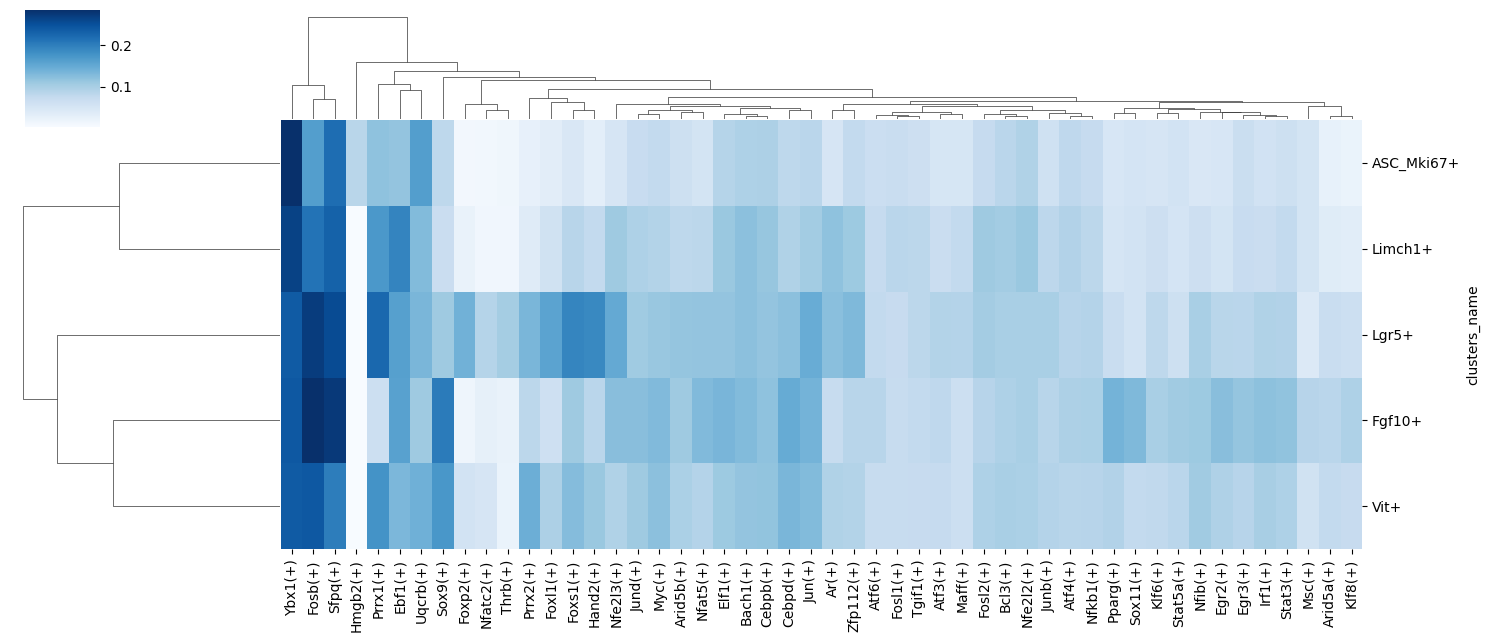

In [11]:
sns.clustermap(
    mean_auc_by_cell_type_top_n,
    figsize=[15, 6.5],
    cmap="Blues",
    xticklabels=True,
    yticklabels=True,
)

As the red heatmap is suggesting that some TFs are strongly associated to particular cell types, we can verify the expression of their expression levels as an additional validation. This is done by matching the TF names we want to highlight, and visualize those using Scanpy’s (red heatmap).

In [12]:
tf_names = top_tfs.index.str.replace(r"\(\+\)", "", regex=True)
adata_batch_top_tfs = adata[:, adata.var_names.isin(tf_names)]

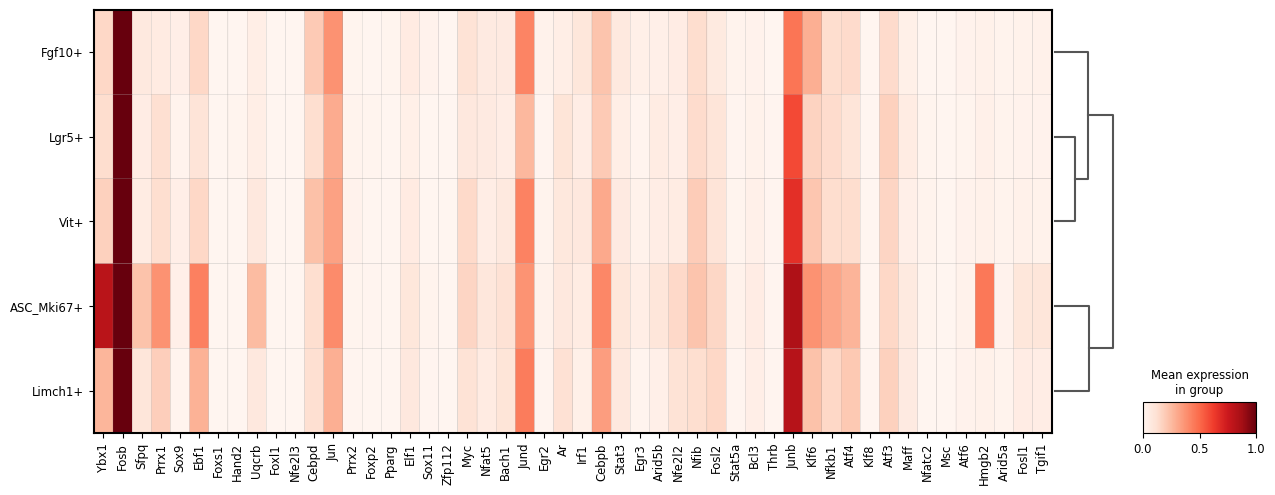

In [13]:
sc.pl.matrixplot(
    adata,
    tf_names,
    groupby="clusters_name",
    cmap="Reds",
    dendrogram=True,
    figsize=[15, 5.5],
    standard_scale="group",
)

### by cluster for each condition :

In [51]:
lf = lp.connect( f_pyscenic_output, mode='r+', validate=False )
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [15]:
auc_mtx["cluster_cond"] = adata.obs['cluster_cond']

In [16]:
mean_auc_by_cell_type = auc_mtx.groupby("cluster_cond").mean()

C:\Users\mxlab\AppData\Local\Temp\ipykernel_20484\2017360564.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_auc_by_cell_type = auc_mtx.groupby("cluster_cond").mean()


In [17]:
top_n = 50
top_tfs = mean_auc_by_cell_type.max(axis=0).sort_values(ascending=False).head(top_n)
mean_auc_by_cell_type_top_n = mean_auc_by_cell_type[
    [c for c in mean_auc_by_cell_type.columns if c in top_tfs]
]

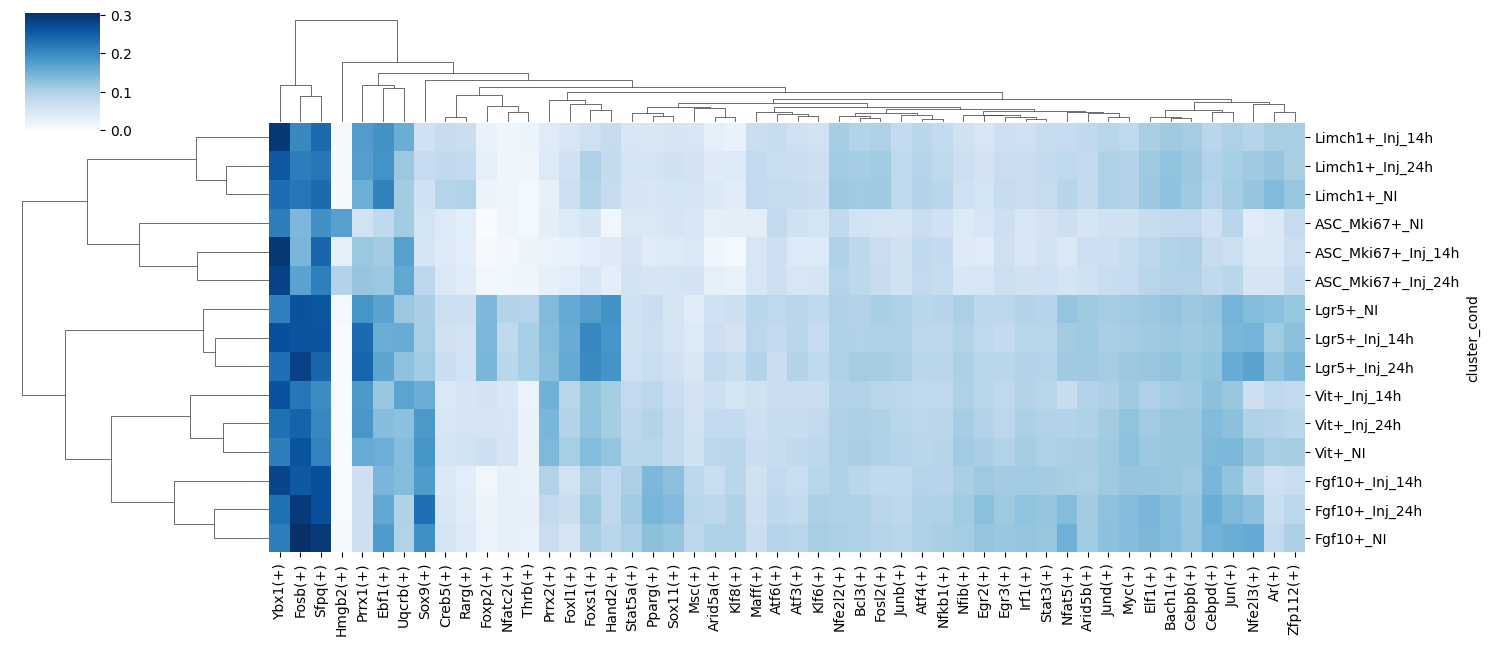

In [18]:
sns.clustermap(
    mean_auc_by_cell_type_top_n,
    figsize=[15, 6.5],
    cmap="Blues",
    xticklabels=True,
    yticklabels=True,
)

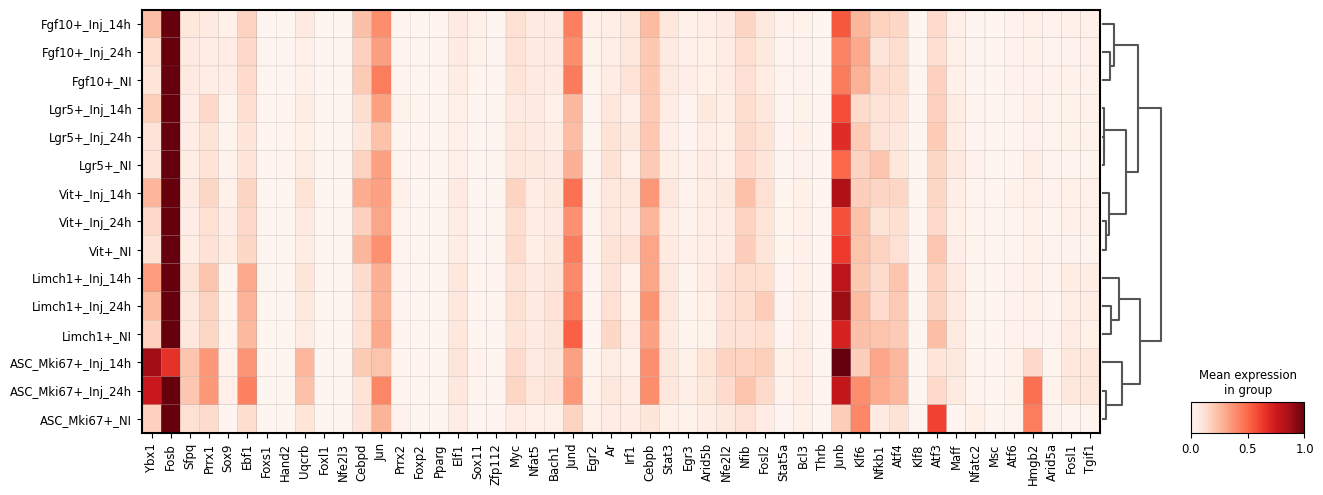

In [123]:
sc.pl.matrixplot(
    adata,
    tf_names,
    groupby="cluster_cond",
    cmap="Reds",
    dendrogram=True,
    figsize=[15, 5.5],
    standard_scale="group",
)

### Visualization of SCENIC's AUC matrix

In [22]:
auc_mtx

,AU041133(+),Alx3(+),Ar(+),Arid3a(+),Arid5a(+),Arid5b(+),Atf2(+),Atf3(+),Atf4(+),Atf6(+),...,Zfp729a(+),Zfp787(+),Zfp821(+),Zfp846(+),Zfp932(+),Zkscan17(+),Zmiz1(+),cluster_cond,condition,clusters_name
scAT_CTL_AAACCCACAGCGGATA-1,0.000000,0.000000,0.074010,0.000000,0.112961,0.091875,0.000000,0.087428,0.095418,0.141219,...,0.000000,0.000000,0.021198,0.035023,0.0,0.084608,0.034123,Fgf10+_NI,NI,Fgf10+
scAT_CTL_AAACCCACATTCACCC-1,0.000000,0.000000,0.132401,0.000000,0.023675,0.059929,0.000000,0.079530,0.070507,0.065233,...,0.000000,0.000000,0.000000,0.027083,0.0,0.028203,0.050149,Limch1+_NI,NI,Limch1+
scAT_CTL_AAACCCAGTAGCGTAG-1,0.000000,0.000000,0.124388,0.017563,0.086636,0.083431,0.000000,0.060142,0.101564,0.087097,...,0.000000,0.013057,0.019355,0.000000,0.0,0.000000,0.041758,Limch1+_NI,NI,Limch1+
scAT_CTL_AAACCCATCGACCTAA-1,0.000000,0.000000,0.128569,0.015617,0.081970,0.100723,0.000000,0.067785,0.111161,0.058321,...,0.018331,0.000000,0.000000,0.000000,0.0,0.000000,0.040047,Fgf10+_NI,NI,Fgf10+
scAT_CTL_AAACGAAAGATTTGCC-1,0.000000,0.001278,0.073115,0.000000,0.053111,0.151273,0.000000,0.069733,0.106959,0.092678,...,0.000000,0.000000,0.082604,0.000000,0.0,0.000000,0.033079,Fgf10+_NI,NI,Fgf10+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scAT_24h_TTTGGTTTCATTACCT-1,0.058618,0.000000,0.092407,0.041526,0.080588,0.086168,0.014483,0.109711,0.081887,0.088479,...,0.017853,0.000000,0.000000,0.000000,0.0,0.000000,0.035327,Fgf10+_Inj_24h,Inj_24h,Fgf10+
scAT_24h_TTTGGTTTCCGCTTAC-1,0.000000,0.022685,0.147534,0.003123,0.010311,0.104360,0.000000,0.072264,0.101245,0.104455,...,0.015498,0.000000,0.000000,0.000000,0.0,0.000000,0.050139,Limch1+_Inj_24h,Inj_24h,Limch1+
scAT_24h_TTTGTTGAGCCTGACC-1,0.000000,0.000000,0.092298,0.000000,0.044297,0.072024,0.000000,0.068674,0.093143,0.086738,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.044155,Limch1+_Inj_24h,Inj_24h,Limch1+
scAT_24h_TTTGTTGCATGACTCA-1,0.000000,0.015698,0.087871,0.000000,0.092224,0.075115,0.000000,0.062436,0.088728,0.082488,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.027142,Vit+_Inj_24h,Inj_24h,Vit+


In [27]:
from pyscenic.binarization import binarize

In [30]:
bin_mtx, thresholds = binarize(auc_mtx)

KeyboardInterrupt: 

In [ ]:
thresholds.to_frame().rename(columns={0:'threshold'}).to_csv('onoff_thresholds.csv')

### Celltype specific regulators - RSS

In [52]:
lf = lp.connect( f_pyscenic_output, mode='r+', validate=False )
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [66]:
adata.obs['cluster_cond'] = adata.obs['clusters_name'].astype(str) + "_" + adata.obs['condition'].astype(str)

In [36]:
from pyscenic.export import add_scenic_metadata
from pyscenic.utils import load_motifs
from pyscenic.transform import df2regulons
from pyscenic.binarization import binarize
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_binarization, plot_rss

In [49]:
np.float = float    
np.int = int   #module 'numpy' has no attribute 'int'
np.object = object    #module 'numpy' has no attribute 'object'
np.bool = bool    #module 'numpy' has no attribute 'bool'

In [72]:
rss = regulon_specificity_scores(auc_mtx, adata.obs.clusters_name)
rss

,AU041133(+),Alx3(+),Ar(+),Arid3a(+),Arid5a(+),Arid5b(+),Atf2(+),Atf3(+),Atf4(+),Atf6(+),...,Zfp629(+),Zfp667(+),Zfp691(+),Zfp729a(+),Zfp787(+),Zfp821(+),Zfp846(+),Zfp932(+),Zkscan17(+),Zmiz1(+)
Fgf10+,0.249777,0.343410,0.385363,0.289975,0.511479,0.480992,0.230663,0.461859,0.454257,0.462444,...,0.218149,0.169253,0.179317,0.261667,0.311171,0.261301,0.215474,0.203749,0.180512,0.411563
Limch1+,0.205239,0.459628,0.599419,0.290965,0.370490,0.497136,0.209868,0.515749,0.535238,0.515380,...,0.201403,0.170097,0.186605,0.297644,0.203984,0.231862,0.251327,0.207663,0.214402,0.577275
Vit+,0.198949,0.282585,0.258045,0.234384,0.278919,0.266237,0.203962,0.262426,0.256917,0.255602,...,0.198394,0.182824,0.179935,0.221648,0.216322,0.217514,0.195401,0.209601,0.178724,0.251936
Lgr5+,0.187250,0.190922,0.196509,0.189428,0.194840,0.196397,0.187192,0.196268,0.190748,0.191188,...,0.191344,0.167445,0.170827,0.173348,0.175412,0.190299,0.182832,0.178679,0.168109,0.194980
ASC_Mki67+,0.172383,0.191260,0.201681,0.178398,0.191805,0.210252,0.176096,0.210741,0.219849,0.219340,...,0.179304,0.167445,0.168001,0.178600,0.178962,0.171124,0.173367,0.225078,0.168272,0.214445


In [75]:
pip install adjustText


  Using cached adjustText-1.3.0-py3-none-any.whl.metadata (3.1 kB)
Using cached adjustText-1.3.0-py3-none-any.whl (13 kB)


In [76]:
from adjustText import adjust_text

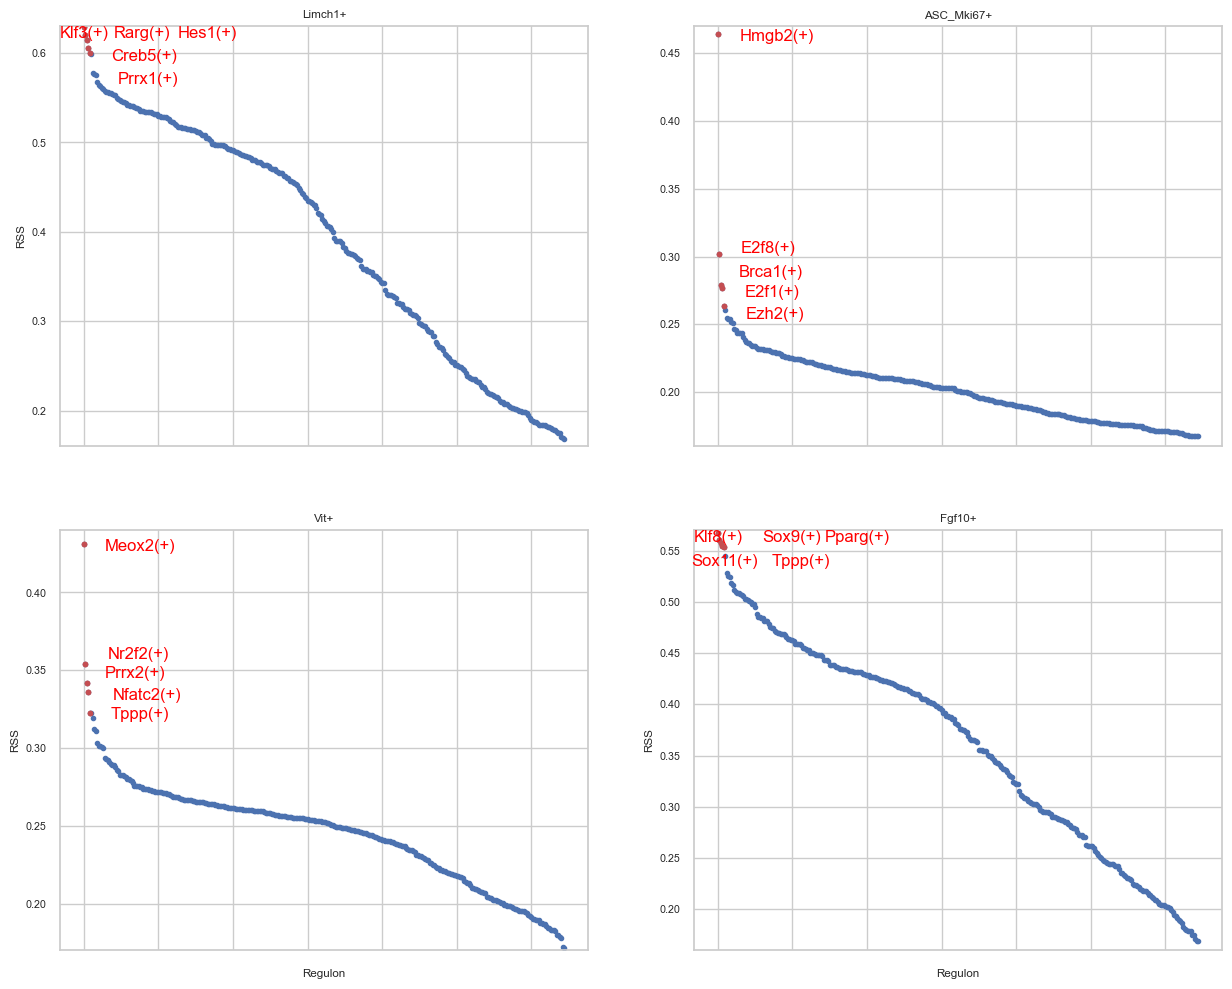

In [77]:
sns.set()
sns.set(style='whitegrid', font_scale=0.7)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
plot_rss(rss, 'Limch1+', ax=ax1)
ax1.set_xlabel('')
plot_rss(rss, 'ASC_Mki67+', ax=ax2)
ax2.set_xlabel('')
ax2.set_ylabel('')
plot_rss(rss, 'Vit+', ax=ax3)
plot_rss(rss, 'Fgf10+', ax=ax4)
ax2.set_xlabel('')
for ax in [ax1, ax2, ax3, ax4]:
    texts = []
    
    # Collect all text elements and adjust them later
    for text in ax.texts:
        text.set_fontsize(12)  # Set your desired font size for text (genes)
        texts.append(text)
    
    # Use adjustText to avoid overlaps
    adjust_text(texts, ax=ax, only_move={'points': 'y', 'text': 'xy'}, force_text=(0.2, 0.2), expand_text=(1.2, 1.2))



In [80]:
rss1 = regulon_specificity_scores(auc_mtx, adata.obs.cluster_cond)
rss1

,AU041133(+),Alx3(+),Ar(+),Arid3a(+),Arid5a(+),Arid5b(+),Atf2(+),Atf3(+),Atf4(+),Atf6(+),...,Zfp629(+),Zfp667(+),Zfp691(+),Zfp729a(+),Zfp787(+),Zfp821(+),Zfp846(+),Zfp932(+),Zkscan17(+),Zmiz1(+)
Fgf10+_NI,0.203547,0.239205,0.252828,0.255440,0.312344,0.283981,0.202271,0.283543,0.273133,0.280104,...,0.206425,0.170455,0.182664,0.225966,0.230113,0.243344,0.196090,0.187061,0.180367,0.259652
Limch1+_NI,0.203658,0.279927,0.315435,0.244287,0.249849,0.268364,0.191847,0.283989,0.284300,0.278837,...,0.180984,0.167445,0.179762,0.245958,0.191773,0.212856,0.238753,0.186816,0.203187,0.299347
Vit+_NI,0.178191,0.198734,0.195779,0.197470,0.203900,0.196688,0.183976,0.196787,0.193220,0.192677,...,0.176635,0.175038,0.178234,0.194286,0.184604,0.188385,0.177016,0.191032,0.178532,0.192367
Lgr5+_NI,0.176858,0.177862,0.179152,0.179283,0.177021,0.178589,0.176889,0.178562,0.176363,0.177142,...,0.187526,0.167445,0.171012,0.169721,0.170036,0.178555,0.171232,0.170490,0.167445,0.178329
ASC_Mki67+_NI,0.167445,0.168521,0.168290,0.167897,0.168397,0.168549,0.167445,0.168974,0.168891,0.169299,...,0.167445,0.167445,0.169036,0.168515,0.170411,0.168903,0.171128,0.167445,0.168803,0.168782
Fgf10+_Inj_14h,0.222800,0.248664,0.250835,0.216014,0.296376,0.292485,0.197059,0.281091,0.283360,0.286053,...,0.185203,0.167445,0.170127,0.201929,0.241985,0.199767,0.189929,0.196475,0.173964,0.265649
Lgr5+_Inj_14h,0.180888,0.177240,0.179007,0.173362,0.178653,0.179818,0.179203,0.179360,0.177216,0.177828,...,0.174179,0.167445,0.168961,0.169479,0.170478,0.178860,0.176362,0.180772,0.167445,0.178742
Limch1+_Inj_14h,0.182873,0.296472,0.337111,0.215102,0.243782,0.314299,0.184189,0.310856,0.323835,0.320009,...,0.183431,0.170572,0.176749,0.223115,0.182847,0.192235,0.208451,0.201331,0.208058,0.341605
Vit+_Inj_14h,0.186725,0.218874,0.200095,0.191759,0.207958,0.205647,0.182441,0.202698,0.201794,0.201802,...,0.180392,0.178933,0.175941,0.187551,0.185487,0.181726,0.178075,0.199023,0.173686,0.199830
ASC_Mki67+_Inj_14h,0.168945,0.174168,0.173882,0.168805,0.170820,0.177197,0.168833,0.175762,0.179270,0.178874,...,0.168320,0.167445,0.167445,0.169166,0.167445,0.167445,0.168544,0.194885,0.167984,0.177725


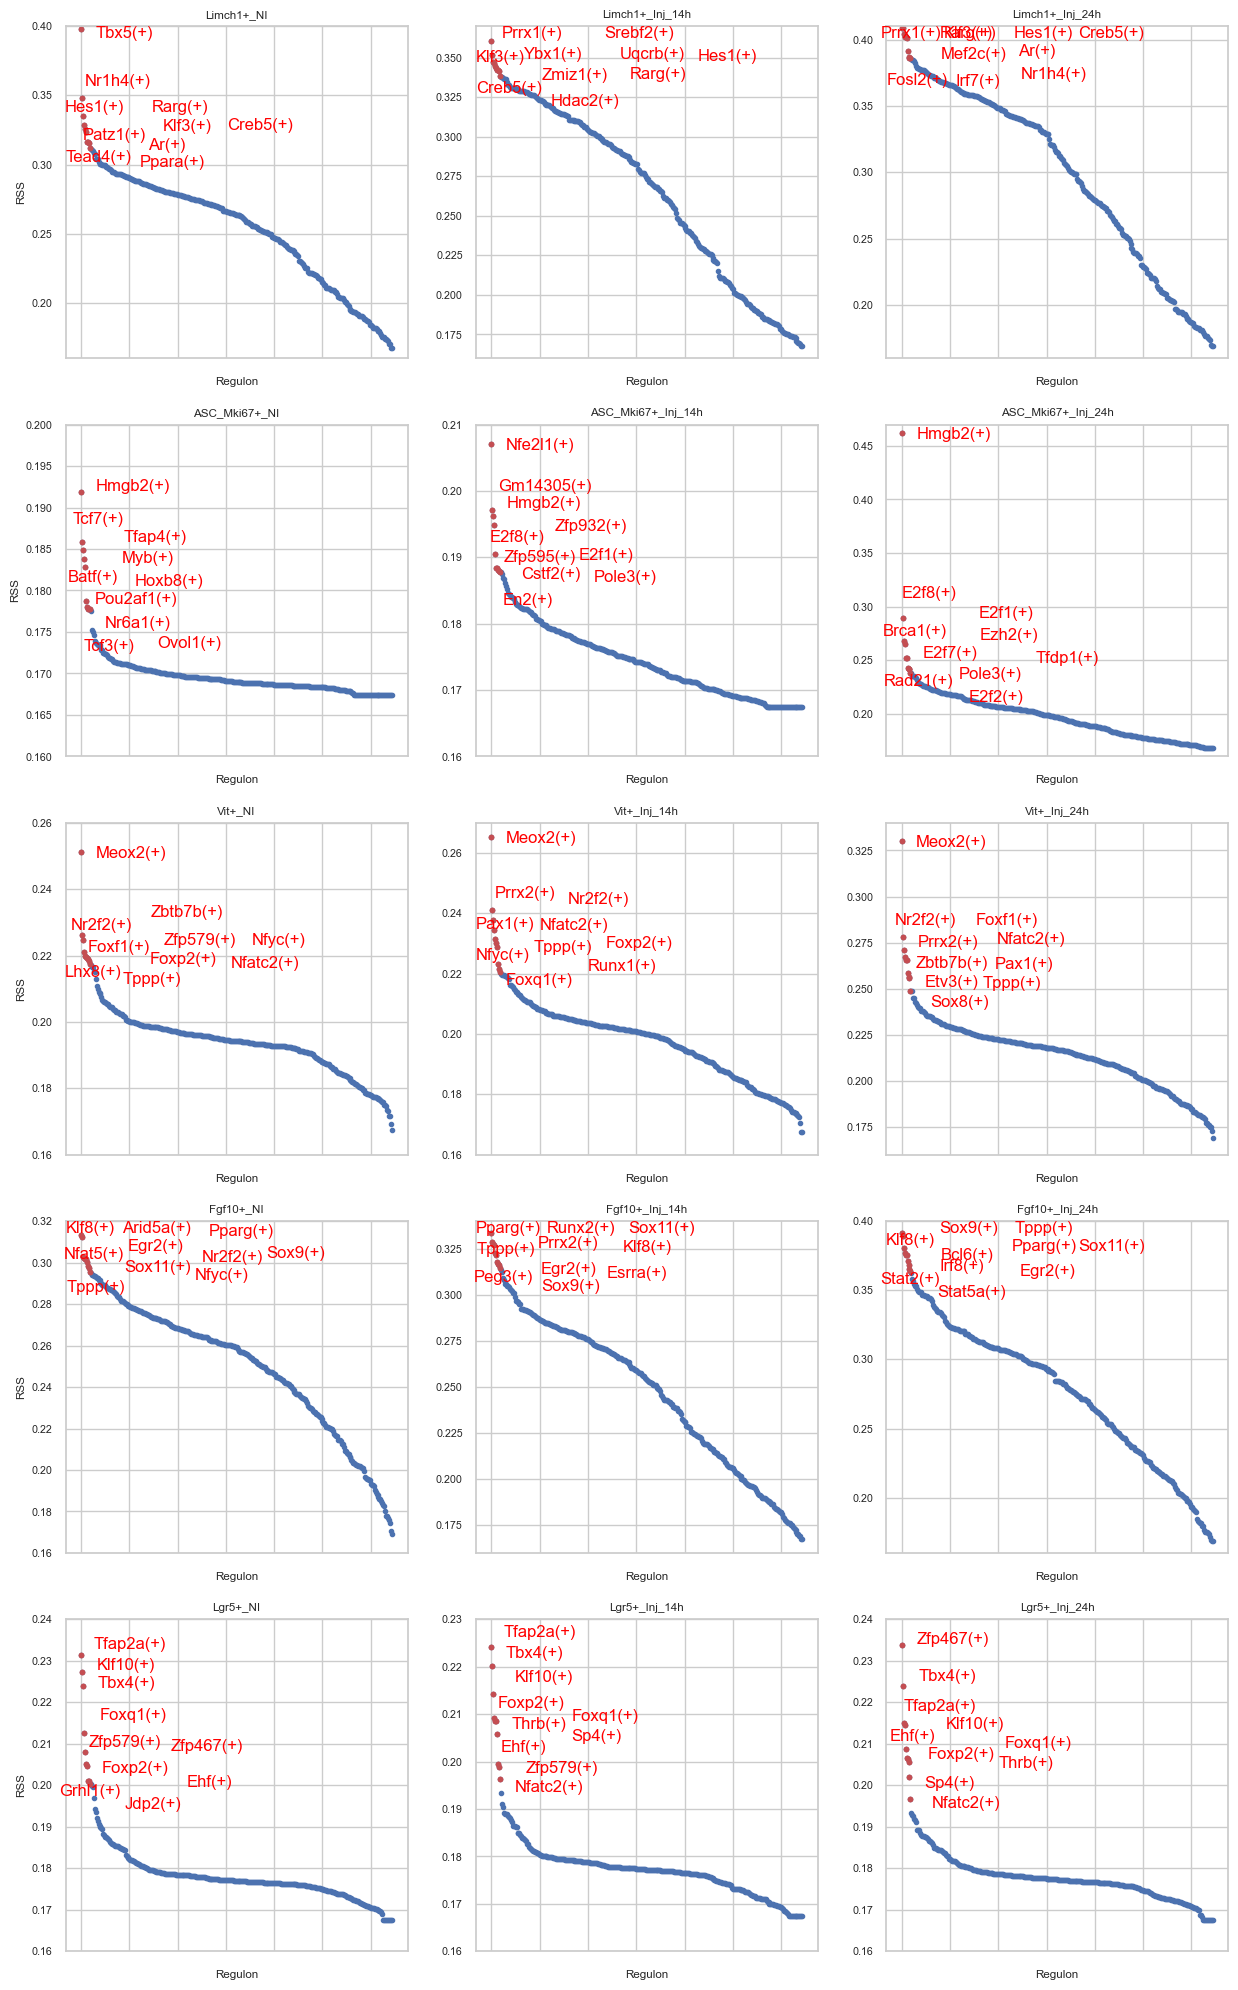

In [87]:
sns.set()
sns.set(style='whitegrid', font_scale=0.7)
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9), (ax10, ax11, ax12), (ax13, ax14, ax15)) = plt.subplots(5, 3, figsize=(15, 25))
plot_rss(rss1, 'Limch1+_NI', ax=ax1, top_n=10)
plot_rss(rss1, 'Limch1+_Inj_14h', ax=ax2, top_n=10)
ax2.set_ylabel('')
plot_rss(rss1, 'Limch1+_Inj_24h', ax=ax3, top_n=10)
ax3.set_ylabel('')

plot_rss(rss1, 'ASC_Mki67+_NI', ax=ax4, top_n=10)
plot_rss(rss1, 'ASC_Mki67+_Inj_14h', ax=ax5, top_n=10)
ax5.set_ylabel('')
plot_rss(rss1, 'ASC_Mki67+_Inj_24h', ax=ax6, top_n=10)
ax6.set_ylabel('')

plot_rss(rss1, 'Vit+_NI', ax=ax7, top_n=10)
plot_rss(rss1, 'Vit+_Inj_14h', ax=ax8, top_n=10)
ax8.set_ylabel('')
plot_rss(rss1, 'Vit+_Inj_24h', ax=ax9, top_n=10)
ax9.set_ylabel('')

plot_rss(rss1, 'Fgf10+_NI', ax=ax10, top_n=10)
plot_rss(rss1, 'Fgf10+_Inj_14h', ax=ax11, top_n=10)
ax11.set_ylabel('')
plot_rss(rss1, 'Fgf10+_Inj_24h', ax=ax12, top_n=10)
ax12.set_ylabel('')

plot_rss(rss1, 'Lgr5+_NI', ax=ax13, top_n=10)
plot_rss(rss1, 'Lgr5+_Inj_14h', ax=ax14, top_n=10)
ax14.set_ylabel('')
plot_rss(rss1, 'Lgr5+_Inj_24h', ax=ax15, top_n=10)
ax15.set_ylabel('')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 , ax10, ax11, ax12, ax13, ax14, ax15]:
    texts = []
    
    # Collect all text elements and adjust them later
    for text in ax.texts:
        text.set_fontsize(12)  # Set your desired font size for text (genes)
        texts.append(text)
    
    # Use adjustText to avoid overlaps
    adjust_text(texts, ax=ax, only_move={'points': 'y', 'text': 'xy'}, force_text=(0.2, 0.2), expand_text=(1.2, 1.2))

### Cell type specific regulators - Z-score

In [100]:
df_motifs = load_motifs('./reg.csv')
regulons = df2regulons(df_motifs)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


In [102]:
add_scenic_metadata(adata, auc_mtx, regulons)

AnnData object with n_obs × n_vars = 9517 × 21695
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tissue', 'condition', 'mitoRatio', 'log10GenesPerUMI', 'multiplet_class', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'predicted.id', 'prediction.score.myeloid.cell', 'prediction.score.T.cell', 'prediction.score.B.cell', 'prediction.score.mesenchymal.stem.cell.of.adipose', 'prediction.score.endothelial.cell', 'prediction.score.V6', 'prediction.score.natural.killer.cell', 'prediction.score.max', 'prediction.score.adipocyte', 'prediction.score.endothelial', 'prediction.score.ASPC', 'prediction.score.macrophage', 'prediction.score.LEC', 'prediction.score.monocyte', 'prediction.score.dendritic_cell', 'prediction.score.SMC', 'prediction.score.pericyte', 'prediction.score.nk_cell', 'prediction.score.mast_cell', 'prediction.score.t_cell', 'prediction.score.b_cell', 'prediction.score.neutrophil', 'celltype_Emont', 'SCT_snn_res.0.15', 'SCT_snn_res.0.1', 'SCT_snn_res.0.

In [108]:
df_obs = adata.obs
signature_column_names = list(df_obs.select_dtypes('number').columns)
signature_column_names = list(filter(lambda s: s.startswith('Regulon('), signature_column_names))
df_scores = df_obs[signature_column_names + ['cluster_cond']]
df_results = ((df_scores.groupby(by='cluster_cond').mean() - df_obs[signature_column_names].mean())/ df_obs[signature_column_names].std()).stack().reset_index().rename(columns={'level_1': 'regulon', 0:'Z'})
df_results['regulon'] = list(map(lambda s: s[8:-1], df_results.regulon))

C:\Users\mxlab\AppData\Local\Temp\ipykernel_20484\1556984876.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results = ((df_scores.groupby(by='cluster_cond').mean() - df_obs[signature_column_names].mean())/ df_obs[signature_column_names].std()).stack().reset_index().rename(columns={'level_1': 'regulon', 0:'Z'})


In [112]:
df_Bresults = df_results[df_results['cluster_cond'] == 'Limch1+_Inj_14h']
df_Bresults.sort_values('Z', ascending=False).head(10)

,cluster_cond,regulon,Z
3197,Limch1+_Inj_14h,Ybx1(+),0.811646
3013,Limch1+_Inj_14h,Hdac2(+),0.624191
3123,Limch1+_Inj_14h,Prrx1(+),0.528250
3057,Limch1+_Inj_14h,Klf3(+),0.517830
3229,Limch1+_Inj_14h,Zmiz1(+),0.503065
3159,Limch1+_Inj_14h,Srebf2(+),0.501341
3219,Limch1+_Inj_14h,Zfp595(+),0.436316
3043,Limch1+_Inj_14h,Irf7(+),0.423314
2939,Limch1+_Inj_14h,Creb5(+),0.395251
3191,Limch1+_Inj_14h,Uqcrb(+),0.360679


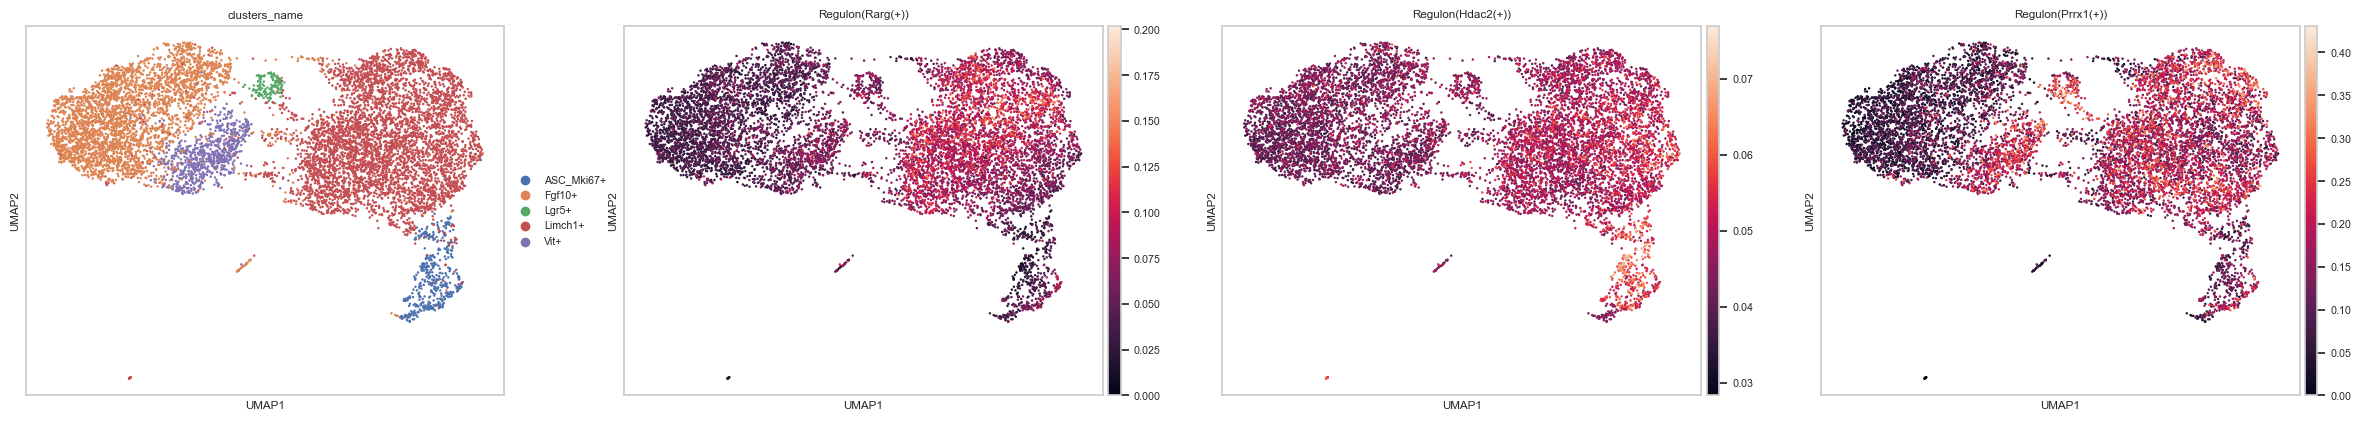

In [ ]:
sc.pl.umap(adata, color = ['clusters_name', 'Regulon(Ybx1(+))', 'Regulon(Hdac2(+))', 'Regulon(Prrx1(+))'])

### UMAP en se basant sur les scores AUCell

In [21]:
auc_mtx["condition"] = adata.obs['condition']
auc_mtx["clusters_name"] = adata.obs['clusters_name']

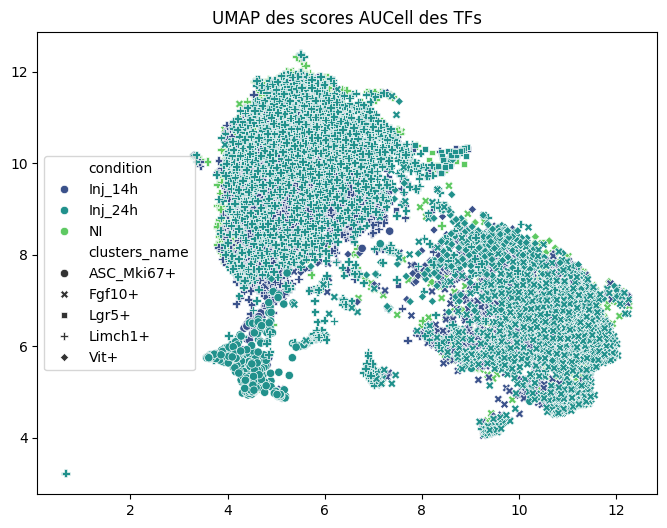

In [25]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Préparer les données
X = auc_mtx.drop(columns=["cluster_cond", "condition", "clusters_name"])  # Garder uniquement les scores TF
X = StandardScaler().fit_transform(X)  # Normaliser

# Appliquer UMAP
umap = UMAP(n_neighbors=15, min_dist=0.1)
embedding = umap.fit_transform(X)

# Visualiser
plt.figure(figsize=(8, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=auc_mtx["condition"], style=auc_mtx["clusters_name"], palette="viridis")
plt.title("UMAP des scores AUCell des TFs")
plt.show()

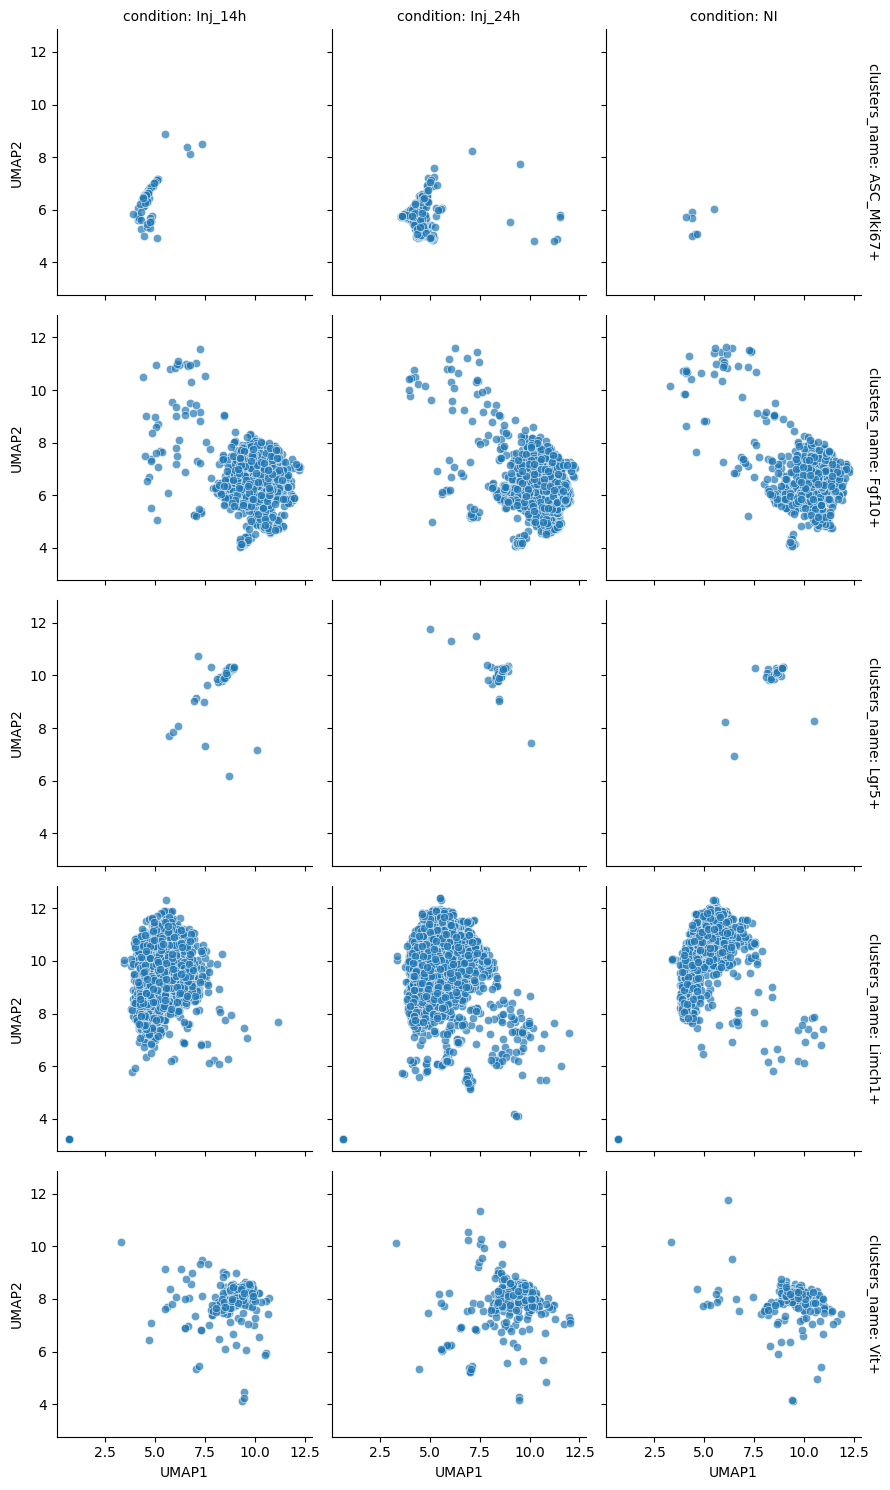

In [26]:
# Ajouter les coordonnées UMAP dans un dataframe
auc_mtx["UMAP1"] = embedding[:, 0]
auc_mtx["UMAP2"] = embedding[:, 1]

# Visualiser avec FacetGrid
g = sns.FacetGrid(auc_mtx, col="condition", row="clusters_name", margin_titles=True, height=3)
g.map_dataframe(sns.scatterplot, x="UMAP1", y="UMAP2", alpha=0.7)
g.set_titles(col_template="condition: {col_name}", row_template="clusters_name: {row_name}")
plt.show()